In [1]:
from pathlib import Path

import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np
from IPython.display import display

from resources import smooth_1d
from resources.cut_off_edges import cut_off_edges
from resources.find_x import (
    calculate_x_profile,
    find_x_area_center, find_x_area_center_split, calculate_x_profile_with_margin,
)
from resources.find_y import (
    calculate_y_profile,
    find_y_argmax, find_y_area_center,
)
from resources.find_z import (
    calculate_z_profile,
    find_z_argmax, find_z_area_center,
)
from resources.rotate_image import rotate_volume
from resources.standarize_image import standardize_image
from resources.find_rotation_error import find_rotation_error, create_rotation_x_profile, find_rotation_error_by_profile

In [2]:
PROJECT_DIR = Path.cwd().parents[2]

DATA_DIR = PROJECT_DIR / "data"
SRC_DIR = PROJECT_DIR / "src"

NIFTI_DIR = PROJECT_DIR / "data" / "niftis"

# UID obrazu do testowania
UID = "15ahdbvz"

In [3]:
file_path = NIFTI_DIR / f"{UID}.nii.gz"

image = nib.load(file_path)
# Obróbka obrazu; funkcja zwraca obiekt NIfTI
processed_image = cut_off_edges(image)
processed_image = cut_off_edges(processed_image,x_left=35,x_right=35,y_front=40,y_back=40,z_down=30,z_up=30)

# processed_image = cut_off_edges(processed_image, x_left=30, x_right=30, y_front=30, y_back=30, z_down=20, z_up=25)
# processed_image = cut_off_edges(processed_image, x_left=25, x_right=25, y_front=25, y_back=25, z_down=20, z_up=20)
# Standaryzacja obrazu
processed_image = standardize_image(processed_image, percent_top=0.02)

volume = processed_image.get_fdata(dtype=np.float32)

x_size, y_size, z_size = volume.shape

print("UID:", UID)
print("Shape:", volume.shape)
print("Voxel size:", image.header.get_zooms()[:3])
print("Orientation:", nib.aff2axcodes(image.affine))

UID: 15ahdbvz
Shape: (74, 86, 64)
Voxel size: (np.float32(2.3), np.float32(2.3), np.float32(2.3))
Orientation: ('R', 'A', 'S')


In [4]:

x_profile = calculate_x_profile(volume)
y_profile = calculate_y_profile(volume)
z_profile = calculate_z_profile(volume)

x_centre = int(find_x_area_center(x_profile))
y_centre = int(find_y_area_center(y_profile))
z_centre = int(find_z_area_center(z_profile))

xyz_centre = (
    x_centre,
    y_centre,
    z_centre,
)

print()
print("Wyznaczony środek:")
print("X:", x_centre)
print("Y:", y_centre)
print("Z:", z_centre)



Wyznaczony środek:
X: 37
Y: 43
Z: 32


In [5]:
# rotation_error = find_rotation_error(cut_off_edges(processed_image,x_left=20,x_right=20,y_front=20,y_back=20,z_down=2,z_up=5))
rotation_error = find_rotation_error_by_profile(processed_image)
rotation_error

3

In [6]:
vmin = volume.min()
vmax = volume.max()
angle_slider = widgets.FloatSlider(
    value=0,
    min=-180,
    max=180,
    step=1,
    description="kąt Z:",
    continuous_update=False,
)

center_x_slider = widgets.IntSlider(
    value=x_centre,
    min=0,
    max=x_size - 1,
    step=1,
    description="center X:",
    continuous_update=False,
)

center_y_slider = widgets.IntSlider(
    value=y_centre,
    min=0,
    max=y_size - 1,
    step=1,
    description="center Y:",
    continuous_update=False,
)

center_z_slider = widgets.IntSlider(
    value=z_centre,
    min=0,
    max=z_size - 1,
    step=1,
    description="center Z:",
    continuous_update=False,
)

z_slice_slider = widgets.IntSlider(
    value=z_centre,
    min=0,
    max=z_size - 1,
    step=1,
    description="slice Z:",
    continuous_update=False,
)
def show_rotation(
    angle,
    center_x,
    center_y,
    center_z,
    z_slice,
):
    volume = processed_image.get_fdata(dtype=np.float32)
    center = (
        center_x,
        center_y,
        center_z,
    )

    rotated_image = rotate_volume(
        image=processed_image,
        angle=angle,
        axis="z",
        center=center,
    )

    rotated_volume = rotated_image.get_fdata(
        dtype=np.float32
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 7),
    )

    axes[0].imshow(
        volume[:, :, z_slice].T,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    axes[0].axvline(
        center_x,
        linestyle="--",
    )

    axes[0].axhline(
        center_y,
        linestyle="--",
    )

    axes[0].scatter(
        center_x,
        center_y,
        marker="+",
        s=200,
    )

    axes[0].set_title(
        f"Oryginał\n"
        f"slice Z = {z_slice}"
    )

    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    axes[1].imshow(
        rotated_volume[:, :, z_slice].T,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    axes[1].axvline(
        center_x,
        linestyle="--",
    )

    axes[1].axhline(
        center_y,
        linestyle="--",
    )

    axes[1].scatter(
        center_x,
        center_y,
        marker="+",
        s=200,
    )

    axes[1].set_title(
        f"Obrót wokół Z: {angle:.1f}°\n"
        f"center = "
        f"({center_x}, {center_y}, {center_z})"
    )

    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")

    plt.tight_layout()
    plt.show()
interactive_view = widgets.interactive(
show_rotation,
angle=angle_slider,
center_x=center_x_slider,
center_y=center_y_slider,
center_z=center_z_slider,
z_slice=z_slice_slider,
)

display(interactive_view)



interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='kąt Z:', max=180.0, min=-18…

([<matplotlib.axis.XTick at 0x21c35e61e20>,
 [Text(0, 0, '0'),
  Text(30, 0, '30'),
  Text(60, 0, '60'),
  Text(90, 0, '90'),
  Text(120, 0, '120'),
  Text(150, 0, '150'),
  Text(180, 0, '180'),
  Text(210, 0, '210'),
  Text(240, 0, '240'),
  Text(270, 0, '270'),
  Text(300, 0, '300'),
  Text(330, 0, '330'),
  Text(360, 0, '360'),
  Text(390, 0, '390')])

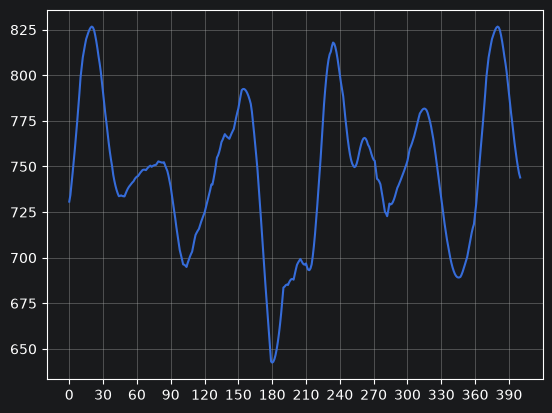

In [7]:
from resources.smooth_1d import smooth_1d
rotation_x_profile = create_rotation_x_profile(processed_image,start=0,end=400)
rotation_x_profile = smooth_1d(rotation_x_profile,window_size=11)
plt.plot(rotation_x_profile)
plt.grid()
plt.xticks(np.arange(0, len(rotation_x_profile), 30))
